In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [81]:
df = pd.read_csv('./data/ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [83]:
df.describe()

,Avg VTAT,Avg CTAT,Cancelled Rides by Customer,Cancelled Rides by Driver,Incomplete Rides,Booking Value,Ride Distance,Driver Ratings,Customer Rating
count,139500.000000,102000.000000,10500.0,27000.0,9000.0,102000.000000,102000.000000,93000.000000,93000.000000
mean,8.456352,29.149636,1.0,1.0,1.0,508.295912,24.637012,4.230992,4.404584
std,3.773564,8.902577,0.0,0.0,0.0,395.805774,14.002138,0.436871,0.437819
min,2.000000,10.000000,1.0,1.0,1.0,50.000000,1.000000,3.000000,3.000000
25%,5.300000,21.600000,1.0,1.0,1.0,234.000000,12.460000,4.100000,4.200000
50%,8.300000,28.800000,1.0,1.0,1.0,414.000000,23.720000,4.300000,4.500000
75%,11.300000,36.800000,1.0,1.0,1.0,689.000000,36.820000,4.600000,4.800000
max,20.000000,45.000000,1.0,1.0,1.0,4277.000000,50.000000,5.000000,5.000000


## Analysis

First, let's prepare the datetime column for time series analysis.

In [84]:
# Convert Date and Time to datetime
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.day_name()
df['Month'] = df['DateTime'].dt.month_name()

print("Date range:", df['Date'].min(), "to", df['Date'].max())
df[['Date', 'Time', 'DateTime', 'Hour', 'DayOfWeek']].head()

Date range: 2024-01-01 00:00:00 to 2024-12-30 00:00:00


,Date,Time,DateTime,Hour,DayOfWeek
0,2024-03-23,12:29:38,2024-03-23 12:29:38,12,Saturday
1,2024-11-29,18:01:39,2024-11-29 18:01:39,18,Friday
2,2024-08-23,08:56:10,2024-08-23 08:56:10,8,Friday
3,2024-10-21,17:17:25,2024-10-21 17:17:25,17,Monday
4,2024-09-16,22:08:00,2024-09-16 22:08:00,22,Monday


### Daily Bookings Over Time (Line Plot)

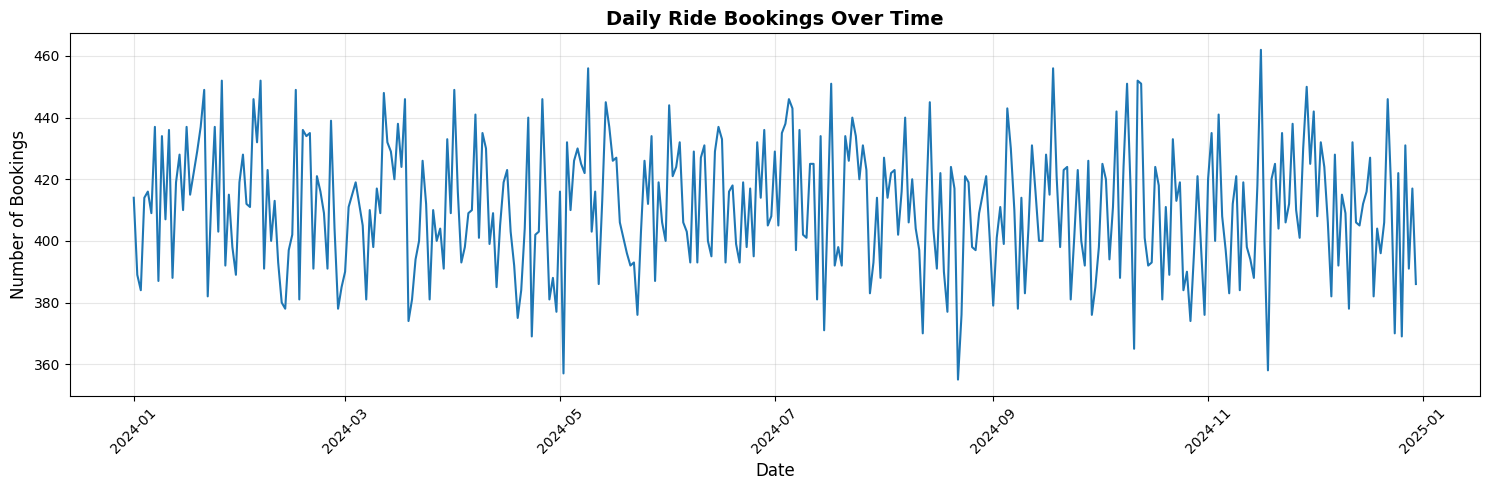

In [85]:
# Daily bookings trend
daily_bookings = df.groupby('Date').size().reset_index(name='Bookings')

plt.figure(figsize=(15, 5))
plt.plot(daily_bookings['Date'], daily_bookings['Bookings'], linewidth=1.5, color='#1f77b4')
plt.title('Daily Ride Bookings Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hourly Bookings Pattern (Bar Plot)

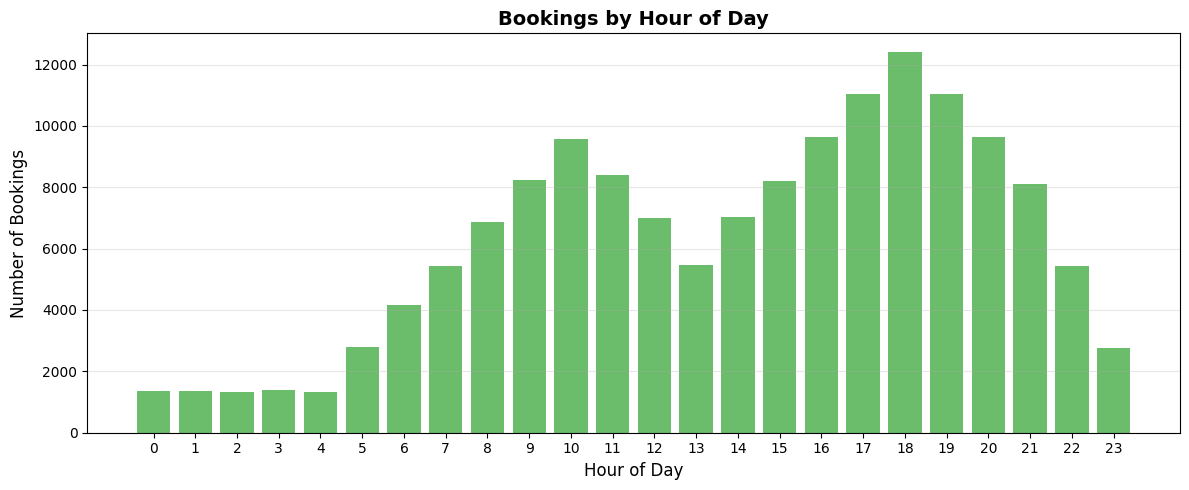

In [86]:
# Hourly bookings pattern
hourly_bookings = df.groupby('Hour').size().reset_index(name='Bookings')

plt.figure(figsize=(12, 5))
plt.bar(hourly_bookings['Hour'], hourly_bookings['Bookings'], color='#2ca02c', alpha=0.7)
plt.title('Bookings by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Weekly Pattern (Day of Week Analysis)

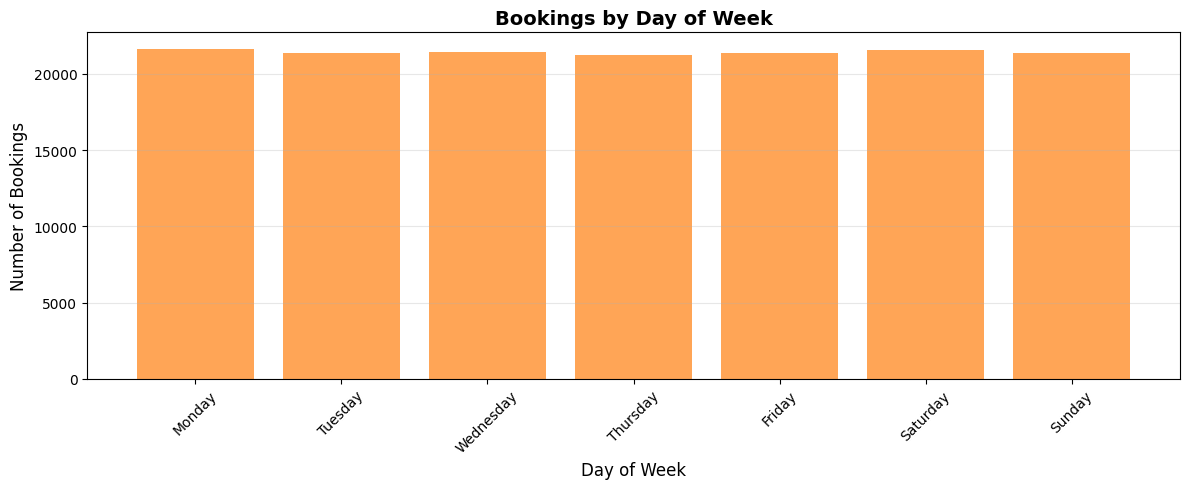

In [87]:
# Day of week pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_bookings = df.groupby('DayOfWeek').size().reindex(day_order).reset_index(name='Bookings')

plt.figure(figsize=(12, 5))
plt.bar(dow_bookings['DayOfWeek'], dow_bookings['Bookings'], color='#ff7f0e', alpha=0.7)
plt.title('Bookings by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Monthly Trend with Rolling Average

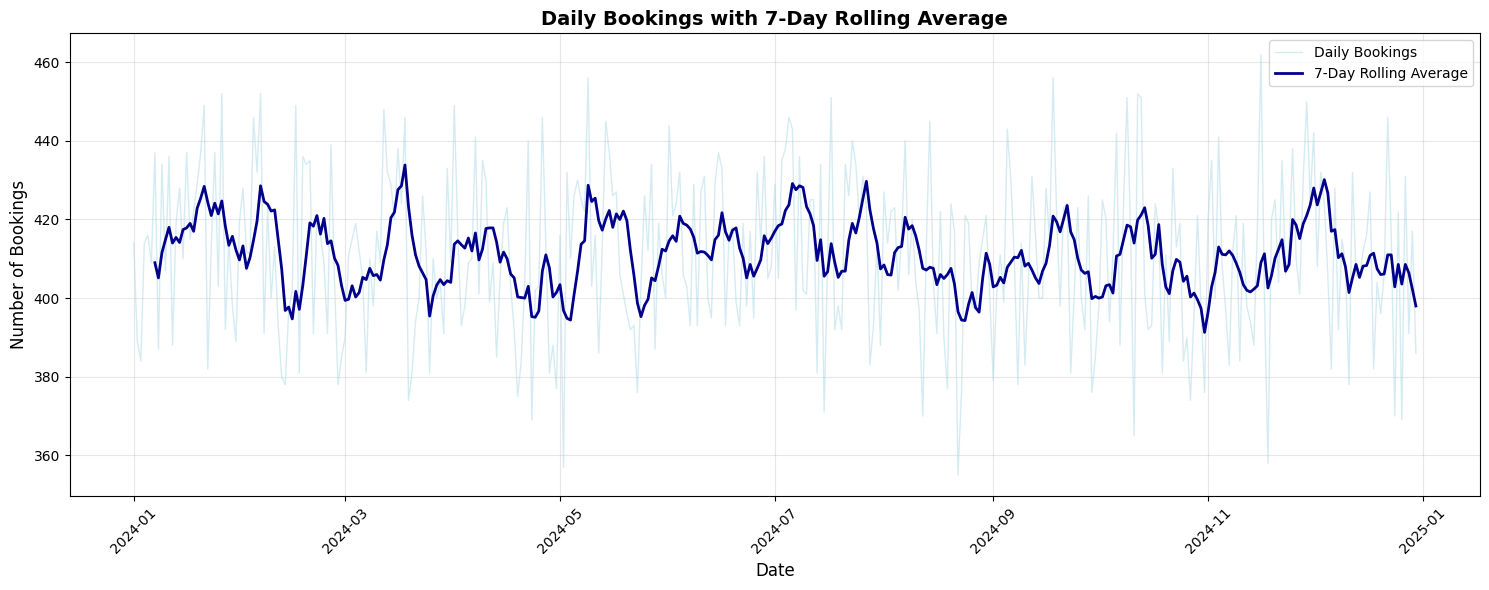

In [88]:
# Daily bookings with 7-day rolling average
daily_bookings = df.groupby('Date').size().reset_index(name='Bookings')
daily_bookings['Rolling_Avg_7'] = daily_bookings['Bookings'].rolling(window=7).mean()

plt.figure(figsize=(15, 6))
plt.plot(daily_bookings['Date'], daily_bookings['Bookings'], 
         alpha=0.5, linewidth=1, label='Daily Bookings', color='lightblue')
plt.plot(daily_bookings['Date'], daily_bookings['Rolling_Avg_7'], 
         linewidth=2, label='7-Day Rolling Average', color='darkblue')
plt.title('Daily Bookings with 7-Day Rolling Average', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Hour vs Day of Week

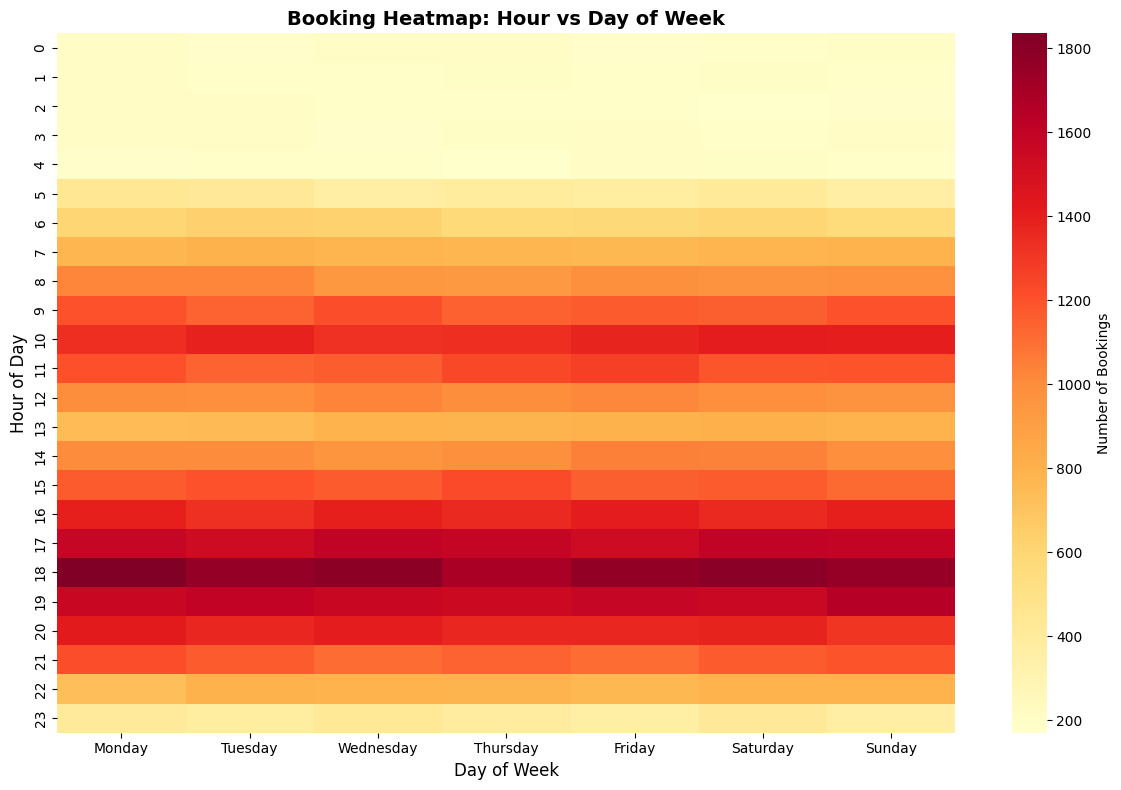

In [89]:
# Create a pivot table for heatmap
df['DayOfWeek_Num'] = df['DateTime'].dt.dayofweek
heatmap_data = df.groupby(['Hour', 'DayOfWeek']).size().reset_index(name='Bookings')
heatmap_pivot = heatmap_data.pivot(index='Hour', columns='DayOfWeek', values='Bookings')

# Reorder columns
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_pivot = heatmap_pivot[day_order]

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_pivot, cmap='YlOrRd', annot=False, fmt='d', cbar_kws={'label': 'Number of Bookings'})
plt.title('Booking Heatmap: Hour vs Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Hour of Day', fontsize=12)
plt.tight_layout()
plt.show()

### Booking Status Over Time (Stacked Area Chart)

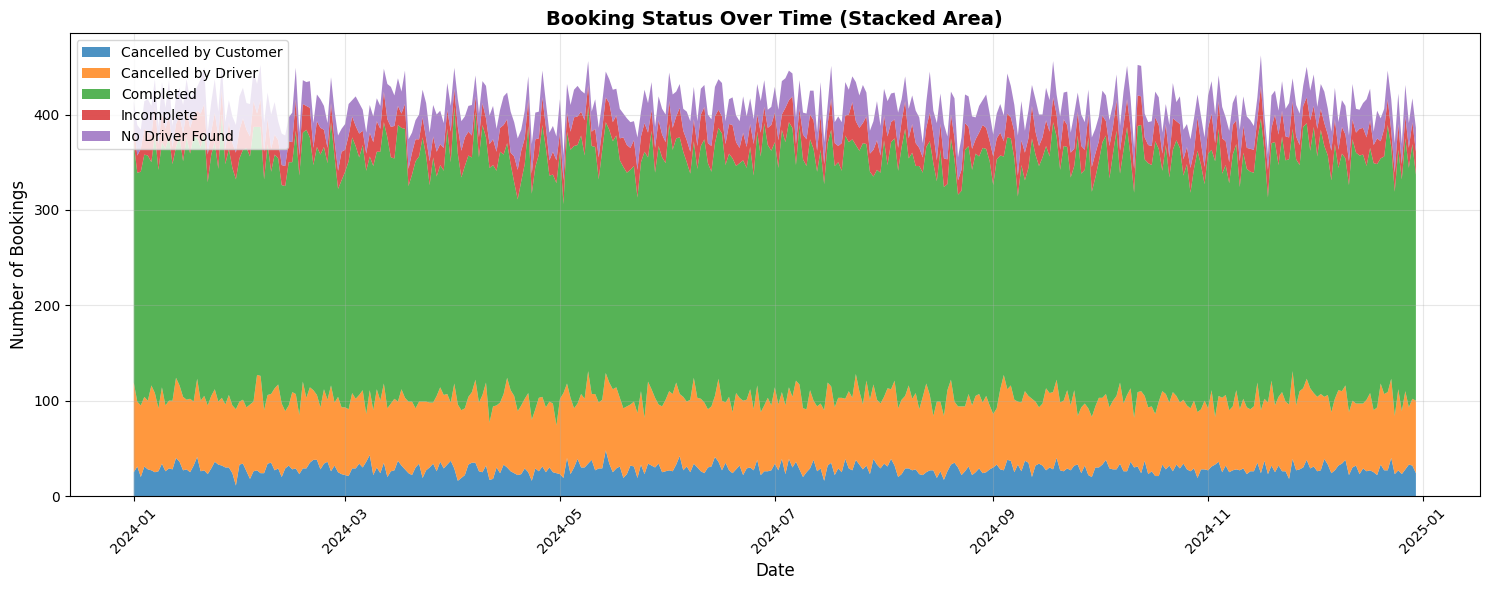

In [90]:
# Booking status over time
status_daily = df.groupby(['Date', 'Booking Status']).size().reset_index(name='Count')
status_pivot = status_daily.pivot(index='Date', columns='Booking Status', values='Count').fillna(0)

plt.figure(figsize=(15, 6))
plt.stackplot(status_pivot.index, 
              [status_pivot[col] for col in status_pivot.columns],
              labels=status_pivot.columns,
              alpha=0.8)
plt.title('Booking Status Over Time (Stacked Area)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Multiple Time Series: Bookings by Vehicle Type

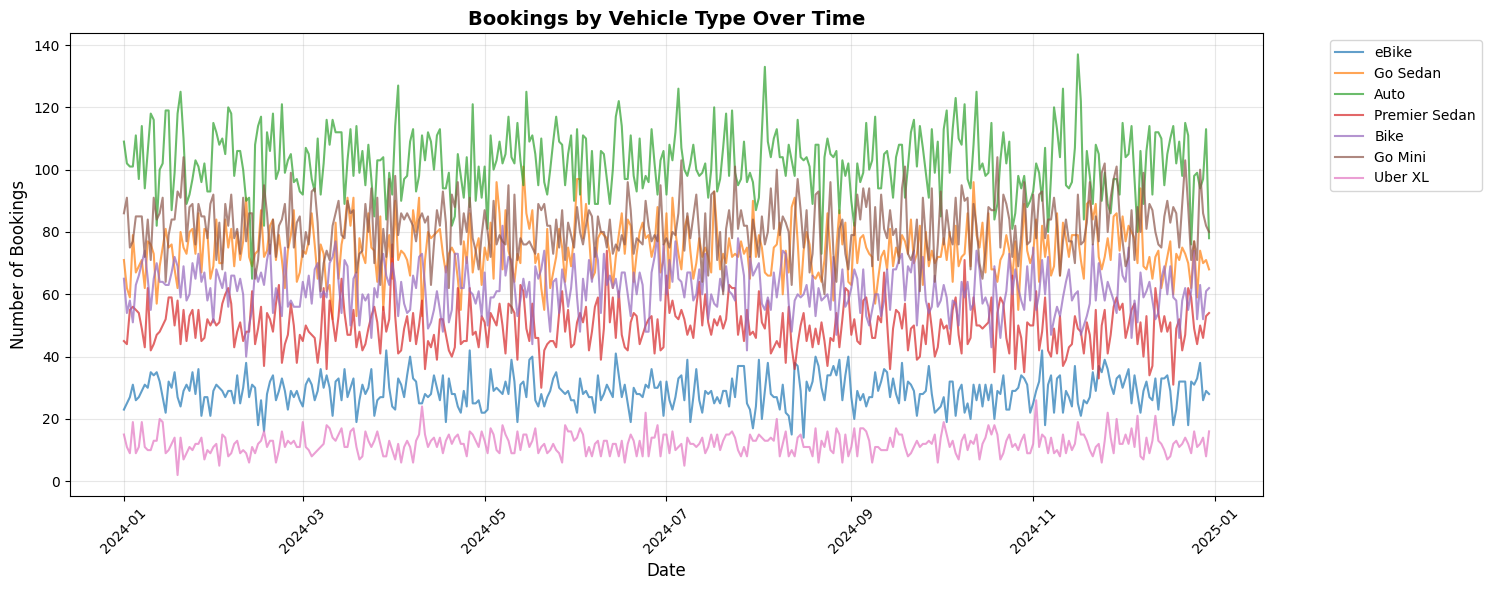

In [91]:
# Bookings by vehicle type over time
vehicle_daily = df.groupby(['Date', 'Vehicle Type']).size().reset_index(name='Count')

plt.figure(figsize=(15, 6))
for vehicle in df['Vehicle Type'].unique():
    if pd.notna(vehicle):
        data = vehicle_daily[vehicle_daily['Vehicle Type'] == vehicle]
        plt.plot(data['Date'], data['Count'], label=vehicle, linewidth=1.5, alpha=0.7)

plt.title('Bookings by Vehicle Type Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Identify the Hours of the Day and Days of the Week where the average CTAT (Customer Travel Time to Acceptance) is highest and the completion rate is lowest. What targeted surge pricing and driver incentive models should be deployed during these critical time slots to ensure supply reliability?

In [92]:
ctat_flat = df.groupby(['DayOfWeek', 'Hour'])['Avg CTAT'].mean().reset_index()
print(ctat_flat.sort_values('Avg CTAT', ascending=False).head(10))
# ctat_flat['CompletionRate'] = 

     DayOfWeek  Hour   Avg CTAT
51    Saturday     3  31.203101
4       Friday     4  30.352273
122    Tuesday     2  30.252740
144  Wednesday     0  30.236567
157  Wednesday    13  30.129084
72      Sunday     0  30.048252
75      Sunday     3  29.998450
28      Monday     4  29.983333
80      Sunday     8  29.966061
23      Friday    23  29.965702


In [93]:
completion_stats = df.groupby(['DayOfWeek', 'Hour']).agg(
    Total_Bookings=('Booking Status', 'count'),
    Completed_Bookings=('Booking Status', lambda x: (x == 'Completed').sum())
).reset_index()
completion_stats['Completion_Rate'] = (
    completion_stats['Completed_Bookings'] / completion_stats['Total_Bookings'] * 100
)
print(completion_stats.sort_values('Completion_Rate', ascending=True).head(10))

    DayOfWeek  Hour  Total_Bookings  Completed_Bookings  Completion_Rate
49   Saturday     1             201                 111        55.223881
25     Monday     1             209                 118        56.459330
62   Saturday    14            1036                 602        58.108108
53   Saturday     5             412                 240        58.252427
133   Tuesday    13             753                 439        58.300133
46     Monday    22             728                 425        58.379121
28     Monday     4             183                 107        58.469945
129   Tuesday     9            1141                 669        58.632778
109  Thursday    13             786                 462        58.778626
55   Saturday     7             776                 458        59.020619


In [94]:
criticality = ctat_flat.merge(
    completion_stats,
    on=['DayOfWeek', 'Hour']
)
criticality['CTAT Normalized'] = (
    (criticality['Avg CTAT'] - criticality['Avg CTAT'].min()) / 
    (criticality['Avg CTAT'].max() - criticality['Avg CTAT'].min()) * 100
)
criticality['CompletionRate_Inverted'] = 100 - criticality['Completion_Rate']
CTAT_WEIGHT = 0.5
COMPLETION_WEIGHT = 0.5

criticality['Criticality_Score'] = (
    criticality['CTAT Normalized'] * CTAT_WEIGHT + 
    criticality['CompletionRate_Inverted'] * COMPLETION_WEIGHT
)

criticality.sort_values('Criticality_Score', ascending=False).head(15)[['DayOfWeek', 'Hour', 'Criticality_Score']]

,DayOfWeek,Hour,Criticality_Score
51,Saturday,3,67.894737
4,Friday,4,60.027871
144,Wednesday,0,58.904860
28,Monday,4,57.733708
75,Sunday,3,57.473312
122,Tuesday,2,57.079879
72,Sunday,0,56.662233
157,Wednesday,13,56.243332
86,Sunday,14,55.747088
123,Tuesday,3,55.557278


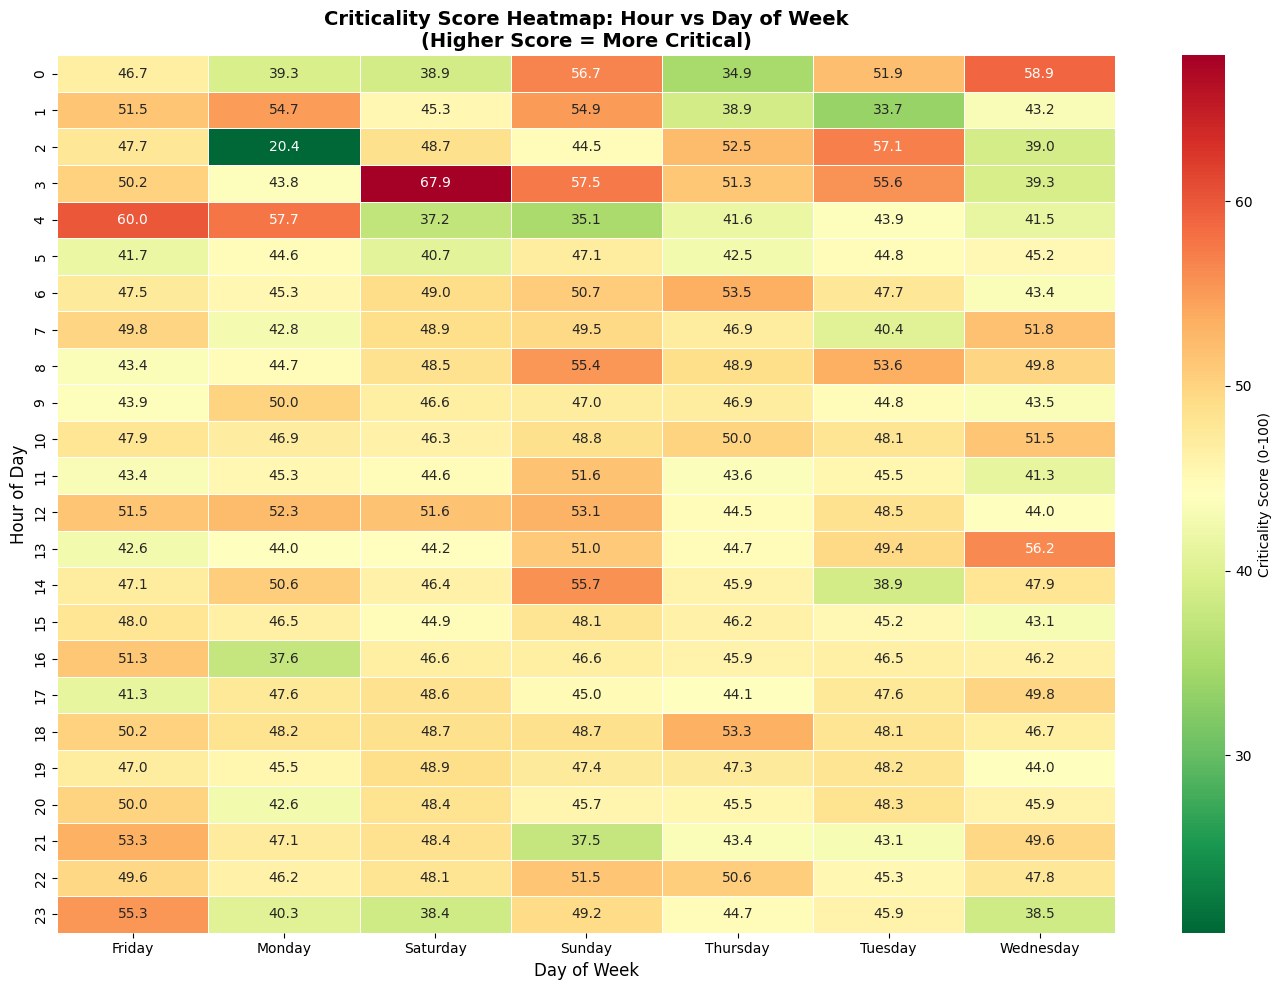

In [95]:
criticality_pivot = criticality.pivot(
    index='Hour', 
    columns='DayOfWeek', 
    values='Criticality_Score'
)
plt.figure(figsize=(14, 10))
sns.heatmap(criticality_pivot, cmap='RdYlGn_r', annot=True, fmt='.1f', 
            cbar_kws={'label': 'Criticality Score (0-100)'}, linewidths=0.5)
plt.title('Criticality Score Heatmap: Hour vs Day of Week\n(Higher Score = More Critical)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Hour of Day', fontsize=12)
plt.tight_layout()
plt.show()

TIME CLUSTER ANALYSIS
                             Avg CTAT  Completion Rate %  Total Bookings  \
Time_Cluster                                                               
Lunch Peak (12:00-13:59)        29.27              61.81           12476   
Morning Rush (08:00-09:59)      29.20              61.96           15095   
Evening Rush (17:00-19:59)      29.17              61.69           34488   
Night (20:00-22:59)             29.16              62.33           23174   
Late Night (00:00-04:59)        29.16              62.45            6776   
Late Morning (10:00-11:59)      29.15              62.54           17967   
Afternoon (14:00-16:59)         29.07              61.65           24866   
Early Morning (05:00-07:59)     29.08              61.88           12396   
Late Night (23:00-23:59)        28.94              62.34            2762   

                             Avg Criticality  
Time_Cluster                                  
Lunch Peak (12:00-13:59)               48.39  


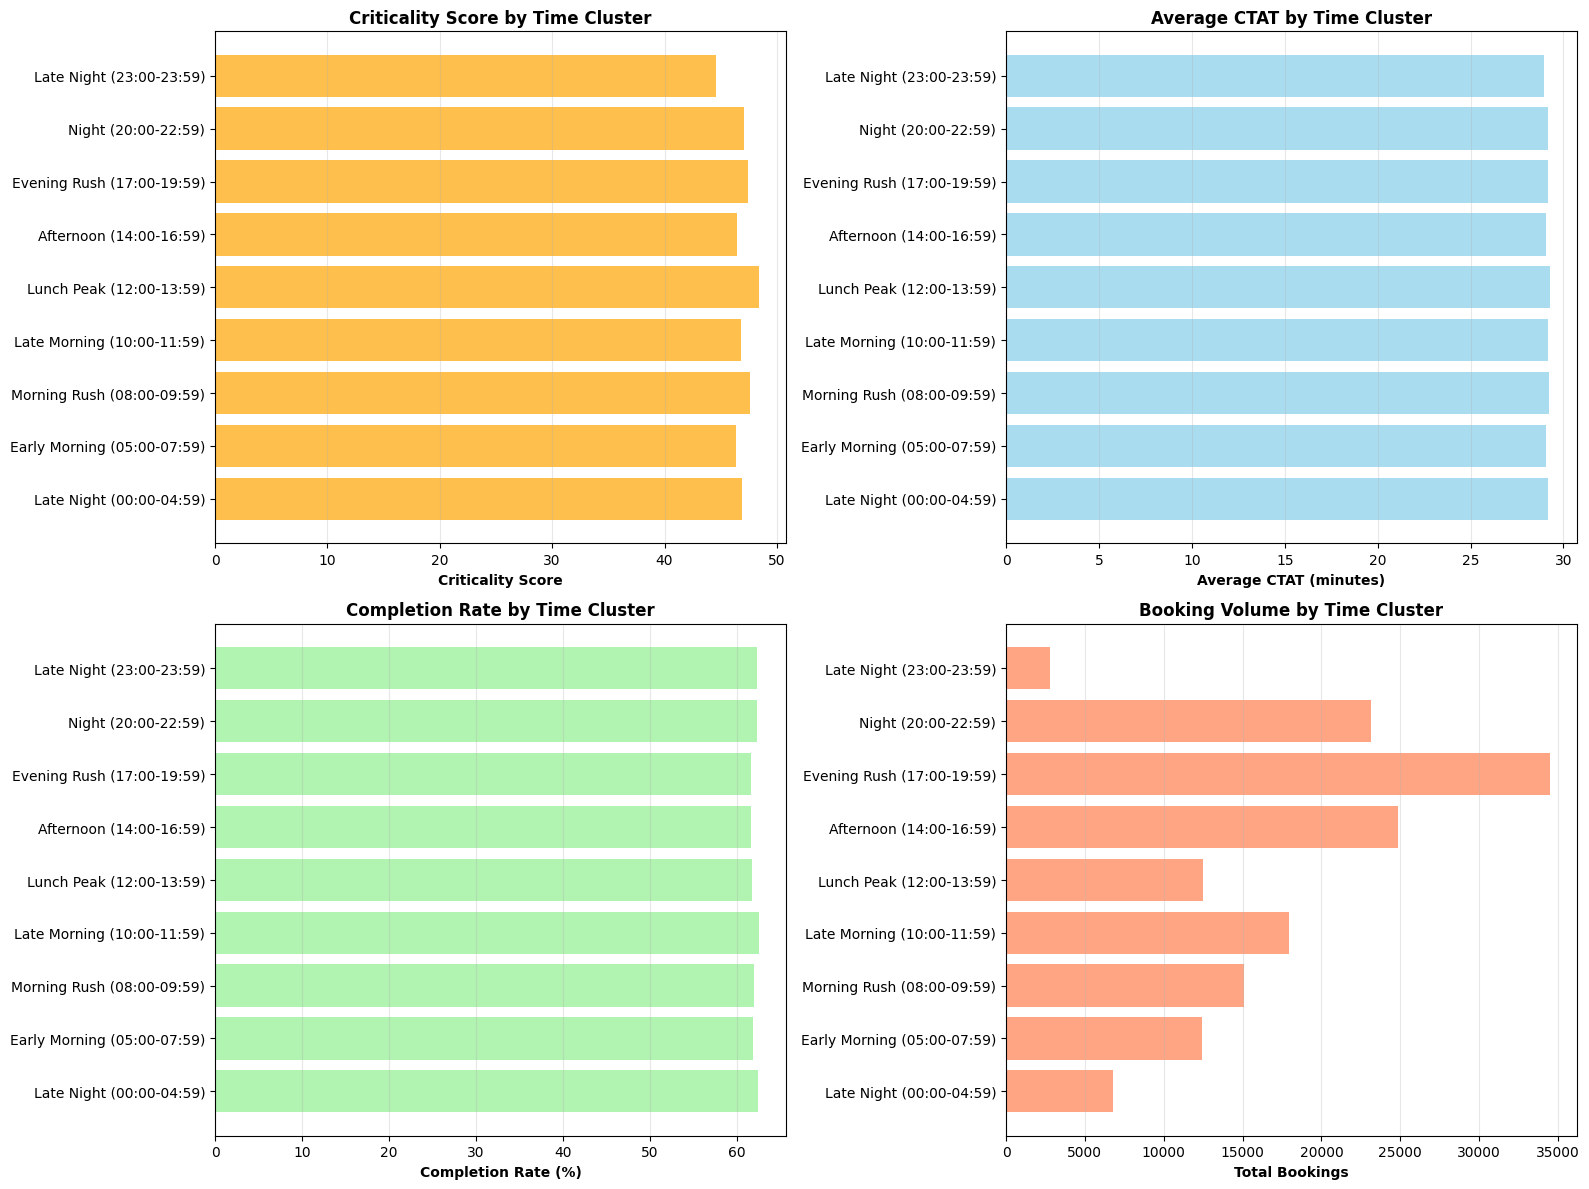

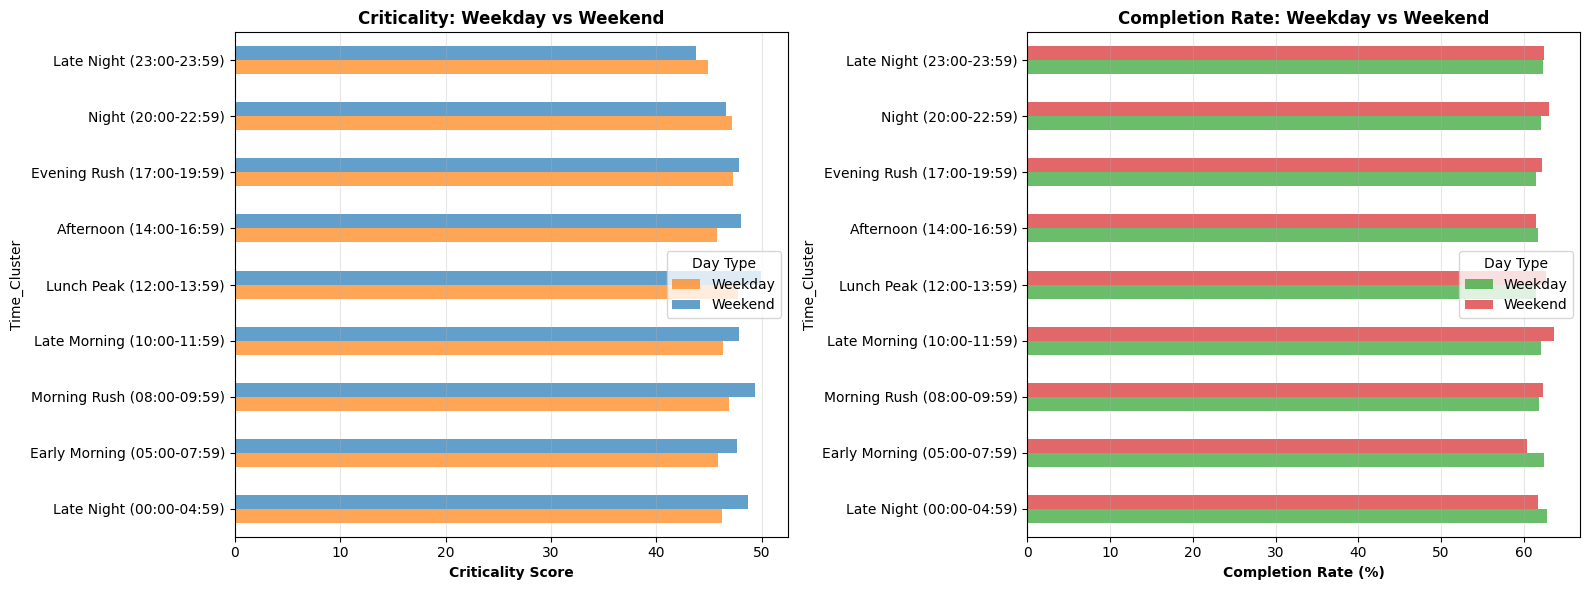


ACTIONABLE RECOMMENDATIONS BY CLUSTER
                             Criticality_Score  Total_Bookings Priority  \
Time_Cluster                                                              
Lunch Peak (12:00-13:59)                 48.39           12476   MEDIUM   
Morning Rush (08:00-09:59)               47.65           15095   MEDIUM   
Evening Rush (17:00-19:59)               47.44           34488   MEDIUM   
Night (20:00-22:59)                      47.05           23174   MEDIUM   
Late Night (00:00-04:59)                 46.92            6776   MEDIUM   
Late Morning (10:00-11:59)               46.77           17967   MEDIUM   
Afternoon (14:00-16:59)                  46.43           24866   MEDIUM   
Early Morning (05:00-07:59)              46.37           12396   MEDIUM   
Late Night (23:00-23:59)                 44.62            2762   MEDIUM   

                            Surge_Multiplier Driver_Incentive  
Time_Cluster                                                   
Lunch P

In [106]:
# Define time period clusters
def assign_time_cluster(hour):
    """Assign time slots to business-relevant periods"""
    if 0 <= hour < 5:
        return 'Late Night (00:00-04:59)'
    elif 5 <= hour < 8:
        return 'Early Morning (05:00-07:59)'
    elif 8 <= hour < 10:
        return 'Morning Rush (08:00-09:59)'
    elif 10 <= hour < 12:
        return 'Late Morning (10:00-11:59)'
    elif 12 <= hour < 14:
        return 'Lunch Peak (12:00-13:59)'
    elif 14 <= hour < 17:
        return 'Afternoon (14:00-16:59)'
    elif 17 <= hour < 20:
        return 'Evening Rush (17:00-19:59)'
    elif 20 <= hour < 23:
        return 'Night (20:00-22:59)'
    else:
        return 'Late Night (23:00-23:59)'

# Apply clustering to the data
criticality['Time_Cluster'] = criticality['Hour'].apply(assign_time_cluster)

# Define day type clusters
def assign_day_type(day):
    """Classify days into weekend/weekday"""
    if day in ['Saturday', 'Sunday']:
        return 'Weekend'
    else:
        return 'Weekday'

criticality['Day_Type'] = criticality['DayOfWeek'].apply(assign_day_type)

# Create combined cluster
criticality['Combined_Cluster'] = (
    criticality['Day_Type'] + ' - ' + criticality['Time_Cluster']
)

# Analyze by time clusters
print("="*80)
print("TIME CLUSTER ANALYSIS")
print("="*80)
cluster_analysis = criticality.groupby('Time_Cluster').agg({
    'Avg CTAT': 'mean',
    'Completion_Rate': 'mean',
    'Total_Bookings': 'sum',
    'Criticality_Score': 'mean'
}).round(2)
cluster_analysis.columns = ['Avg CTAT', 'Completion Rate %', 'Total Bookings', 'Avg Criticality']

# Sort by criticality
cluster_analysis = cluster_analysis.sort_values('Avg Criticality', ascending=False)
print(cluster_analysis)

# Analyze by combined clusters (Day Type + Time Period)
print("\n" + "="*80)
print("WEEKDAY vs WEEKEND COMPARISON BY TIME CLUSTER")
print("="*80)
pivot_analysis = criticality.pivot_table(
    index='Time_Cluster',
    columns='Day_Type',
    values=['Avg CTAT', 'Completion_Rate', 'Criticality_Score'],
    aggfunc='mean'
).round(2)
print(pivot_analysis)

# Identify top critical clusters
print("\n" + "="*80)
print("TOP 5 MOST CRITICAL COMBINED CLUSTERS")
print("="*80)
top_clusters = criticality.groupby('Combined_Cluster').agg({
    'Avg CTAT': 'mean',
    'Completion_Rate': 'mean',
    'Total_Bookings': 'sum',
    'Criticality_Score': 'mean'
}).round(2).sort_values('Criticality_Score', ascending=False).head(10)
top_clusters.columns = ['Avg CTAT', 'Completion Rate %', 'Total Bookings', 'Avg Criticality']
print(top_clusters)

# Visualization 1: Criticality by Time Cluster
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Average Criticality Score by Time Cluster
cluster_order = [
    'Late Night (00:00-04:59)', 'Early Morning (05:00-07:59)', 
    'Morning Rush (08:00-09:59)', 'Late Morning (10:00-11:59)',
    'Lunch Peak (12:00-13:59)', 'Afternoon (14:00-16:59)',
    'Evening Rush (17:00-19:59)', 'Night (20:00-22:59)',
    'Late Night (23:00-23:59)'
]
cluster_crit = criticality.groupby('Time_Cluster')['Criticality_Score'].mean().reindex(cluster_order)
colors_crit = ['red' if x > 60 else 'orange' if x > 40 else 'green' for x in cluster_crit.values]
axes[0, 0].barh(cluster_crit.index, cluster_crit.values, color=colors_crit, alpha=0.7)
axes[0, 0].set_xlabel('Criticality Score', fontweight='bold')
axes[0, 0].set_title('Criticality Score by Time Cluster', fontweight='bold', fontsize=12)
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: CTAT by Time Cluster
cluster_ctat = criticality.groupby('Time_Cluster')['Avg CTAT'].mean().reindex(cluster_order)
axes[0, 1].barh(cluster_ctat.index, cluster_ctat.values, color='skyblue', alpha=0.7)
axes[0, 1].set_xlabel('Average CTAT (minutes)', fontweight='bold')
axes[0, 1].set_title('Average CTAT by Time Cluster', fontweight='bold', fontsize=12)
axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Completion Rate by Time Cluster
cluster_comp = criticality.groupby('Time_Cluster')['Completion_Rate'].mean().reindex(cluster_order)
axes[1, 0].barh(cluster_comp.index, cluster_comp.values, color='lightgreen', alpha=0.7)
axes[1, 0].set_xlabel('Completion Rate (%)', fontweight='bold')
axes[1, 0].set_title('Completion Rate by Time Cluster', fontweight='bold', fontsize=12)
axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Total Bookings by Time Cluster
cluster_bookings = criticality.groupby('Time_Cluster')['Total_Bookings'].sum().reindex(cluster_order)
axes[1, 1].barh(cluster_bookings.index, cluster_bookings.values, color='coral', alpha=0.7)
axes[1, 1].set_xlabel('Total Bookings', fontweight='bold')
axes[1, 1].set_title('Booking Volume by Time Cluster', fontweight='bold', fontsize=12)
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization 2: Weekday vs Weekend Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Compare Criticality: Weekday vs Weekend
day_type_crit = criticality.groupby(['Time_Cluster', 'Day_Type'])['Criticality_Score'].mean().unstack()
day_type_crit = day_type_crit.reindex(cluster_order)
day_type_crit.plot(kind='barh', ax=axes[0], color=['#ff7f0e', '#1f77b4'], alpha=0.7)
axes[0].set_xlabel('Criticality Score', fontweight='bold')
axes[0].set_title('Criticality: Weekday vs Weekend', fontweight='bold', fontsize=12)
axes[0].legend(title='Day Type')
axes[0].grid(axis='x', alpha=0.3)

# Compare Completion Rate: Weekday vs Weekend
day_type_comp = criticality.groupby(['Time_Cluster', 'Day_Type'])['Completion_Rate'].mean().unstack()
day_type_comp = day_type_comp.reindex(cluster_order)
day_type_comp.plot(kind='barh', ax=axes[1], color=['#2ca02c', '#d62728'], alpha=0.7)
axes[1].set_xlabel('Completion Rate (%)', fontweight='bold')
axes[1].set_title('Completion Rate: Weekday vs Weekend', fontweight='bold', fontsize=12)
axes[1].legend(title='Day Type')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Export cluster recommendations
print("\n" + "="*80)
print("ACTIONABLE RECOMMENDATIONS BY CLUSTER")
print("="*80)

recommendations = criticality.groupby('Time_Cluster').agg({
    'Criticality_Score': 'mean',
    'Total_Bookings': 'sum'
}).round(2)

recommendations['Priority'] = recommendations['Criticality_Score'].apply(
    lambda x: 'HIGH' if x > 60 else 'MEDIUM' if x > 40 else 'LOW'
)

recommendations['Surge_Multiplier'] = recommendations['Criticality_Score'].apply(
    lambda x: '2.0-2.5x' if x > 70 else '1.5-2.0x' if x > 50 else '1.2-1.5x' if x > 30 else '1.0x'
)

recommendations['Driver_Incentive'] = recommendations['Criticality_Score'].apply(
    lambda x: 'High Bonus + Streak Multiplier' if x > 70 
    else 'Standard Bonus' if x > 50 
    else 'Base Rate' if x > 30 
    else 'No Incentive'
)

recommendations = recommendations.sort_values('Criticality_Score', ascending=False)
print(recommendations)

GEOGRAPHIC ANALYSIS BY PICKUP LOCATION

TOP 10 CRITICAL PICKUP LOCATIONS:
                 Total_Bookings  Avg_CTAT  Completion_Rate  \
Pickup Location                                              
Jor Bagh                    884     30.08            61.65   
Pragati Maidan              920     29.99            58.48   
Malviya Nagar               885     30.00            62.94   
Mundka                      830     29.87            61.57   
Patel Chowk                 854     29.81            61.94   
Noida Extension             827     29.76            61.06   
Noida Sector 62             834     29.77            61.99   
Manesar                     824     29.76            62.74   
Vidhan Sabha                825     29.69            61.33   
Anand Vihar                 859     29.72            64.38   

                 Location_Criticality  
Pickup Location                        
Jor Bagh                        75.34  
Pragati Maidan                  73.80  
Malviya Nagar        

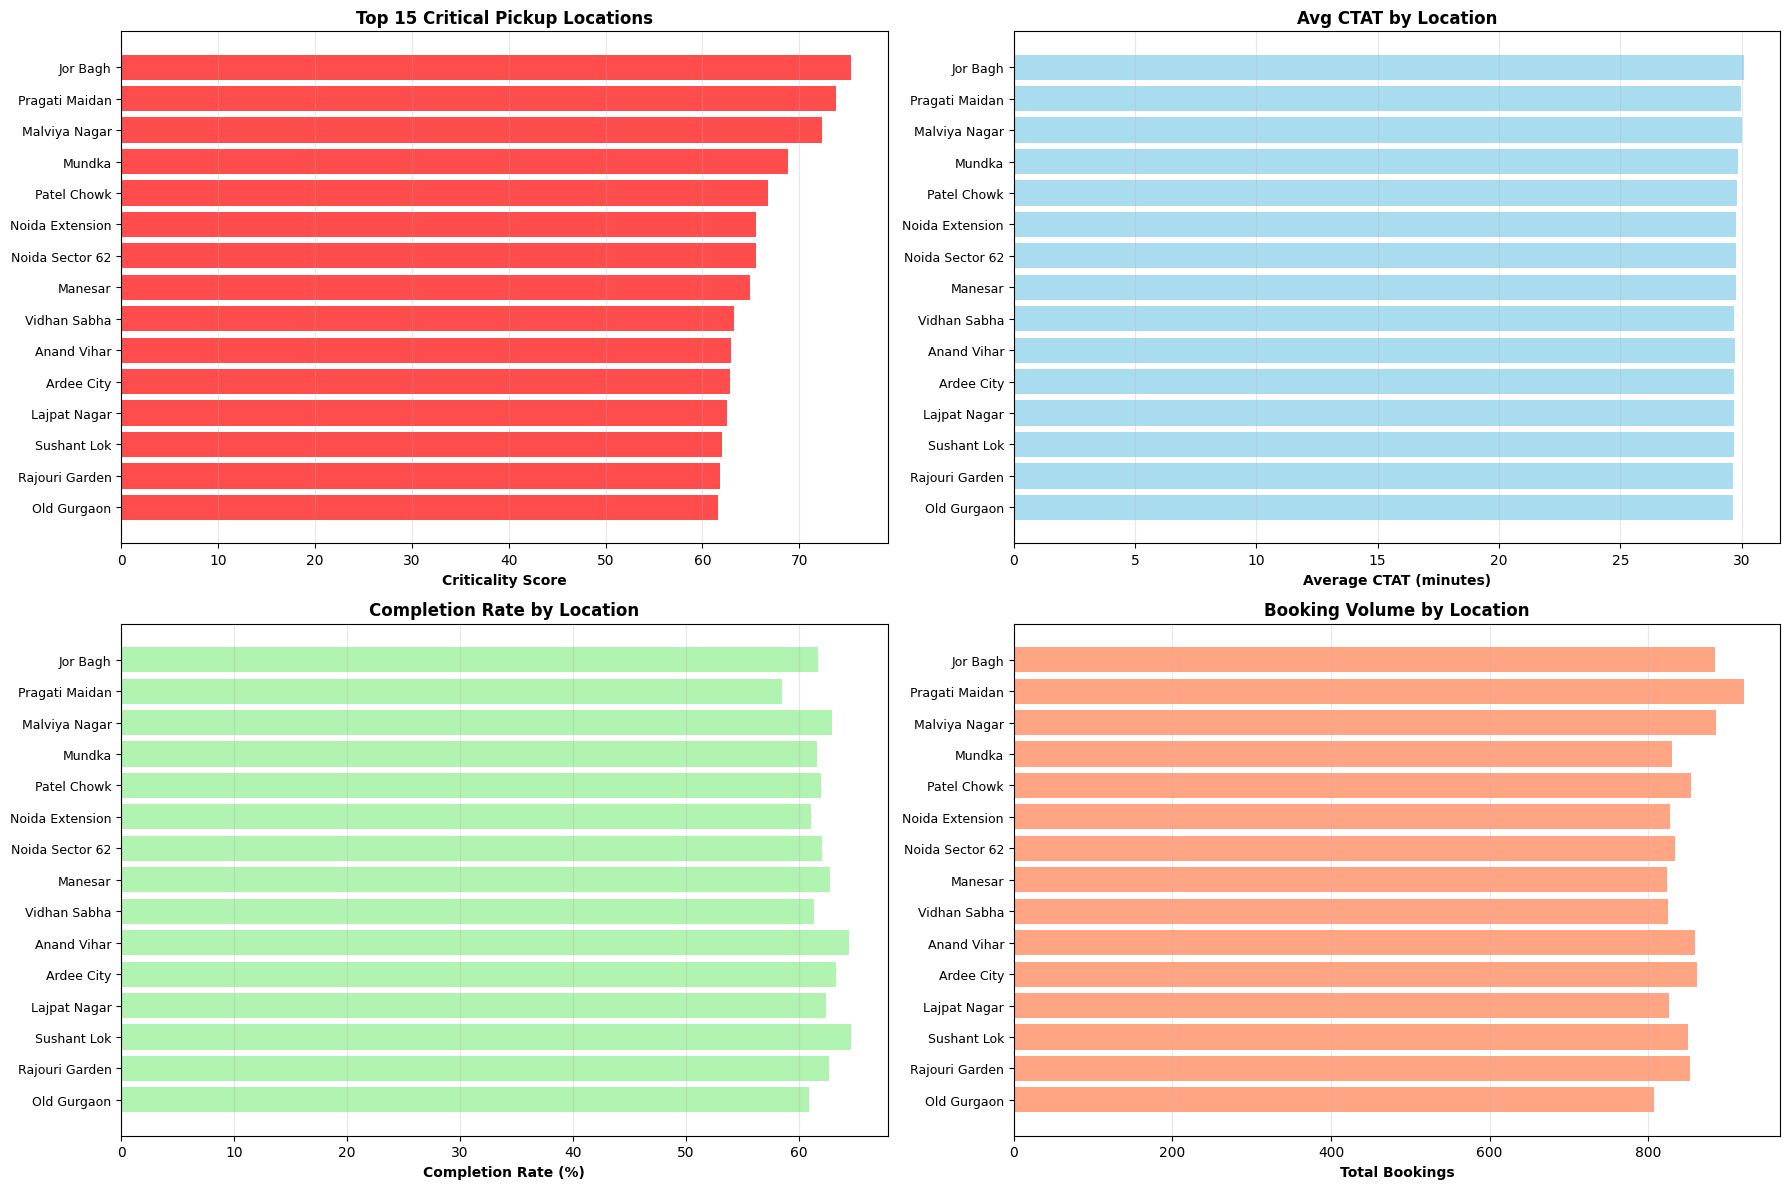

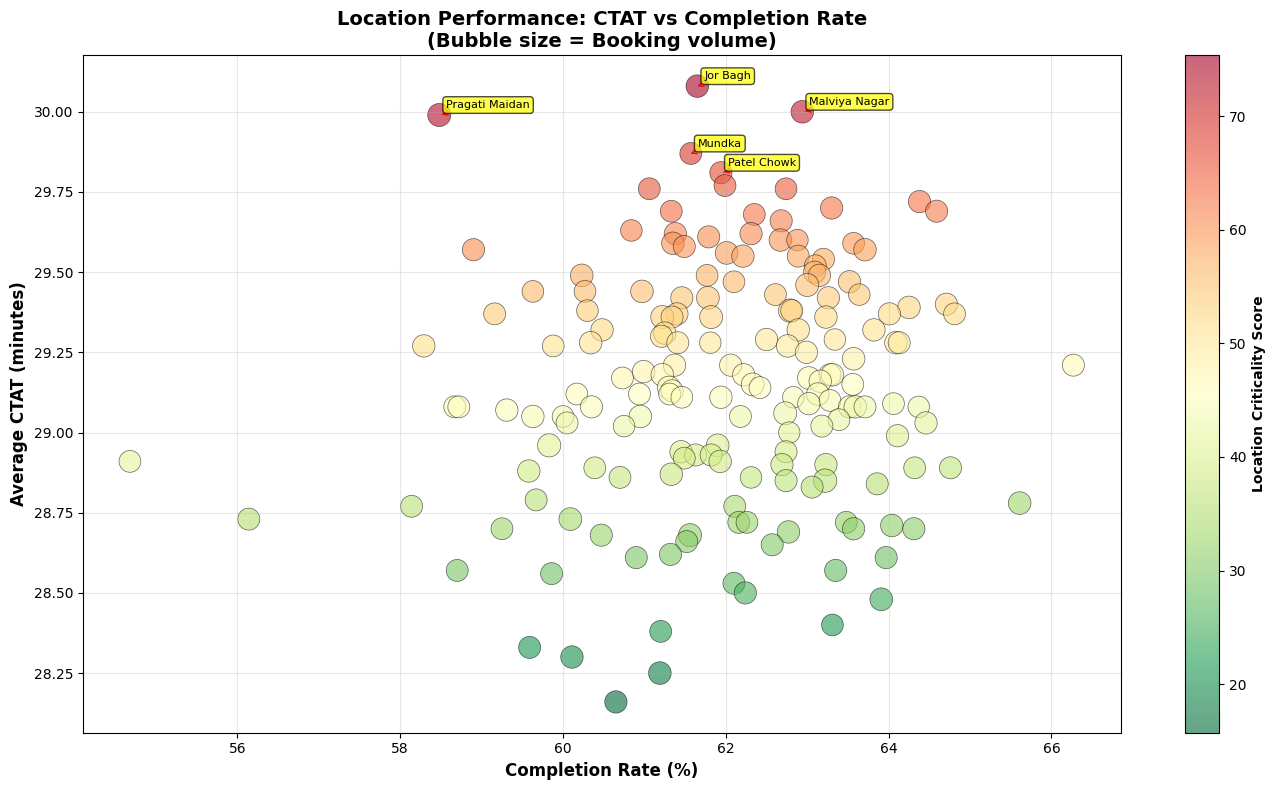

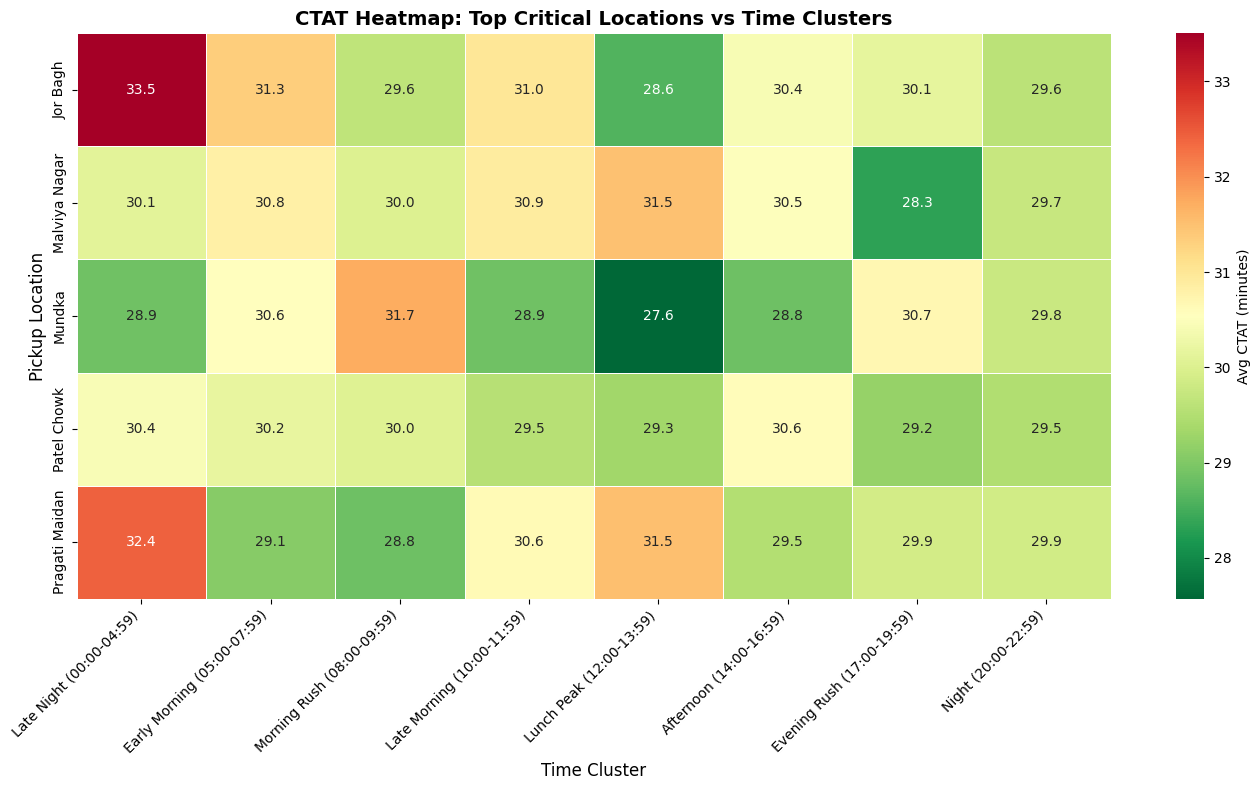


LOCATION-SPECIFIC SURGE PRICING RECOMMENDATIONS
                 Total_Bookings  Avg_CTAT  Completion_Rate  \
Pickup Location                                              
Jor Bagh                    884     30.08            61.65   
Pragati Maidan              920     29.99            58.48   
Malviya Nagar               885     30.00            62.94   
Mundka                      830     29.87            61.57   
Patel Chowk                 854     29.81            61.94   
Noida Extension             827     29.76            61.06   
Noida Sector 62             834     29.77            61.99   
Manesar                     824     29.76            62.74   
Vidhan Sabha                825     29.69            61.33   
Anand Vihar                 859     29.72            64.38   

                 Location_Criticality Priority              Surge_Zone  
Pickup Location                                                         
Jor Bagh                        75.34     HIGH     Red Zone 

In [107]:
# Geographic Analysis by Pickup Location
print("="*80)
print("GEOGRAPHIC ANALYSIS BY PICKUP LOCATION")
print("="*80)

# Calculate metrics by pickup location
location_analysis = df.groupby('Pickup Location').agg({
    'Booking ID': 'count',
    'Avg CTAT': 'mean',
    'Booking Status': [
        ('Total', 'count'),
        ('Completed', lambda x: (x == 'Completed').sum())
    ],
    'Booking Value': 'mean',
    'Ride Distance': 'mean'
}).round(2)

# Flatten column names
location_analysis.columns = ['Total_Bookings', 'Avg_CTAT', 'Total_Rides', 'Completed_Rides', 'Avg_Booking_Value', 'Avg_Distance']
location_analysis['Completion_Rate'] = (location_analysis['Completed_Rides'] / location_analysis['Total_Rides'] * 100).round(2)

# Calculate location criticality score
location_analysis['CTAT_Normalized'] = (
    (location_analysis['Avg_CTAT'] - location_analysis['Avg_CTAT'].min()) / 
    (location_analysis['Avg_CTAT'].max() - location_analysis['Avg_CTAT'].min()) * 100
)
location_analysis['CompletionRate_Inverted'] = 100 - location_analysis['Completion_Rate']
location_analysis['Location_Criticality'] = (
    location_analysis['CTAT_Normalized'] * 0.6 + 
    location_analysis['CompletionRate_Inverted'] * 0.4
).round(2)

# Sort by criticality
location_analysis = location_analysis.sort_values('Location_Criticality', ascending=False)

# Display top critical locations
print("\nTOP 10 CRITICAL PICKUP LOCATIONS:")
print(location_analysis.head(10)[['Total_Bookings', 'Avg_CTAT', 'Completion_Rate', 'Location_Criticality']])

# Time-based analysis by location
print("\n" + "="*80)
print("TIME CLUSTER ANALYSIS BY TOP 5 CRITICAL LOCATIONS")
print("="*80)

# Get top 5 critical locations
top_critical_locations = location_analysis.head(5).index.tolist()

# Merge location with criticality data
location_time_analysis = df[df['Pickup Location'].isin(top_critical_locations)].copy()
location_time_analysis['Time_Cluster'] = location_time_analysis['Hour'].apply(assign_time_cluster)
location_time_analysis['Day_Type'] = location_time_analysis['DayOfWeek'].apply(assign_day_type)

# Aggregate by location and time cluster
location_time_stats = location_time_analysis.groupby(['Pickup Location', 'Time_Cluster']).agg({
    'Booking ID': 'count',
    'Avg CTAT': 'mean',
    'Booking Status': [
        ('Total', 'count'),
        ('Completed', lambda x: (x == 'Completed').sum())
    ]
}).round(2)

location_time_stats.columns = ['Total_Bookings', 'Avg_CTAT', 'Total_Rides', 'Completed_Rides']
location_time_stats['Completion_Rate'] = (
    location_time_stats['Completed_Rides'] / location_time_stats['Total_Rides'] * 100
).round(2)

print(location_time_stats.head(20))

# Visualization 1: Location Criticality Map
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Top 15 Critical Locations
top_15 = location_analysis.head(15)
colors = ['red' if x > 60 else 'orange' if x > 40 else 'green' for x in top_15['Location_Criticality'].values]
axes[0, 0].barh(range(len(top_15)), top_15['Location_Criticality'].values, color=colors, alpha=0.7)
axes[0, 0].set_yticks(range(len(top_15)))
axes[0, 0].set_yticklabels(top_15.index, fontsize=9)
axes[0, 0].set_xlabel('Criticality Score', fontweight='bold')
axes[0, 0].set_title('Top 15 Critical Pickup Locations', fontweight='bold', fontsize=12)
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].invert_yaxis()

# Plot 2: CTAT by Location
axes[0, 1].barh(range(len(top_15)), top_15['Avg_CTAT'].values, color='skyblue', alpha=0.7)
axes[0, 1].set_yticks(range(len(top_15)))
axes[0, 1].set_yticklabels(top_15.index, fontsize=9)
axes[0, 1].set_xlabel('Average CTAT (minutes)', fontweight='bold')
axes[0, 1].set_title('Avg CTAT by Location', fontweight='bold', fontsize=12)
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].invert_yaxis()

# Plot 3: Completion Rate by Location
axes[1, 0].barh(range(len(top_15)), top_15['Completion_Rate'].values, color='lightgreen', alpha=0.7)
axes[1, 0].set_yticks(range(len(top_15)))
axes[1, 0].set_yticklabels(top_15.index, fontsize=9)
axes[1, 0].set_xlabel('Completion Rate (%)', fontweight='bold')
axes[1, 0].set_title('Completion Rate by Location', fontweight='bold', fontsize=12)
axes[1, 0].grid(axis='x', alpha=0.3)
axes[1, 0].invert_yaxis()

# Plot 4: Booking Volume by Location
axes[1, 1].barh(range(len(top_15)), top_15['Total_Bookings'].values, color='coral', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_15)))
axes[1, 1].set_yticklabels(top_15.index, fontsize=9)
axes[1, 1].set_xlabel('Total Bookings', fontweight='bold')
axes[1, 1].set_title('Booking Volume by Location', fontweight='bold', fontsize=12)
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

# Visualization 2: Scatter Plot - Location Performance
plt.figure(figsize=(14, 8))

# Create scatter plot with bubble size for booking volume
scatter = plt.scatter(
    location_analysis['Completion_Rate'],
    location_analysis['Avg_CTAT'],
    s=location_analysis['Total_Bookings'] * 0.3,
    c=location_analysis['Location_Criticality'],
    cmap='RdYlGn_r',
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Location Criticality Score', fontweight='bold')

# Label top 5 critical locations
for idx, location in enumerate(top_critical_locations):
    row = location_analysis.loc[location]
    plt.annotate(
        location[:15] + '...' if len(location) > 15 else location,
        xy=(row['Completion_Rate'], row['Avg_CTAT']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
        arrowprops=dict(arrowstyle='->', color='red', lw=1)
    )

plt.xlabel('Completion Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Average CTAT (minutes)', fontsize=12, fontweight='bold')
plt.title('Location Performance: CTAT vs Completion Rate\n(Bubble size = Booking volume)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualization 3: Heatmap - Time Cluster vs Location
location_time_pivot = location_time_analysis.groupby(
    ['Pickup Location', 'Time_Cluster']
)['Avg CTAT'].mean().unstack(fill_value=0)

# Reorder columns by time cluster
cluster_order = [
    'Late Night (00:00-04:59)', 'Early Morning (05:00-07:59)', 
    'Morning Rush (08:00-09:59)', 'Late Morning (10:00-11:59)',
    'Lunch Peak (12:00-13:59)', 'Afternoon (14:00-16:59)',
    'Evening Rush (17:00-19:59)', 'Night (20:00-22:59)'
]
location_time_pivot = location_time_pivot[[col for col in cluster_order if col in location_time_pivot.columns]]

plt.figure(figsize=(14, 8))
sns.heatmap(location_time_pivot, cmap='RdYlGn_r', annot=True, fmt='.1f', 
            cbar_kws={'label': 'Avg CTAT (minutes)'}, linewidths=0.5)
plt.title('CTAT Heatmap: Top Critical Locations vs Time Clusters', 
          fontsize=14, fontweight='bold')
plt.xlabel('Time Cluster', fontsize=12)
plt.ylabel('Pickup Location', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Generate location-specific recommendations
print("\n" + "="*80)
print("LOCATION-SPECIFIC SURGE PRICING RECOMMENDATIONS")
print("="*80)

location_recommendations = location_analysis.head(10).copy()
location_recommendations['Priority'] = location_recommendations['Location_Criticality'].apply(
    lambda x: 'HIGH' if x > 60 else 'MEDIUM' if x > 40 else 'LOW'
)
location_recommendations['Surge_Zone'] = location_recommendations['Location_Criticality'].apply(
    lambda x: 'Red Zone (2.0-2.5x)' if x > 70 
    else 'Orange Zone (1.5-2.0x)' if x > 50 
    else 'Yellow Zone (1.2-1.5x)' if x > 30 
    else 'Normal Zone (1.0x)'
)

print(location_recommendations[['Total_Bookings', 'Avg_CTAT', 'Completion_Rate', 
                                 'Location_Criticality', 'Priority', 'Surge_Zone']])

VEHICLE TYPE ANALYSIS
               Total_Bookings  Avg_CTAT  Total_Rides  Completed_Rides  \
Vehicle Type                                                            
Go Sedan                27141     29.04        27141            16676   
Premier Sedan           18111     29.22        18111            11252   
Auto                    37419     29.14        37419            23155   
eBike                   10557     29.18        10557             6551   
Bike                    22517     29.20        22517            14034   
Go Mini                 29806     29.16        29806            18549   
Uber XL                  4449     29.21         4449             2783   

               Avg_Value  Avg_VTAT  Completion_Rate  Supply_Issue_Score  
Vehicle Type                                                             
Go Sedan          511.50      8.40            61.44                1.63  
Premier Sedan     509.57      8.44            62.13                1.62  
Auto              506.73

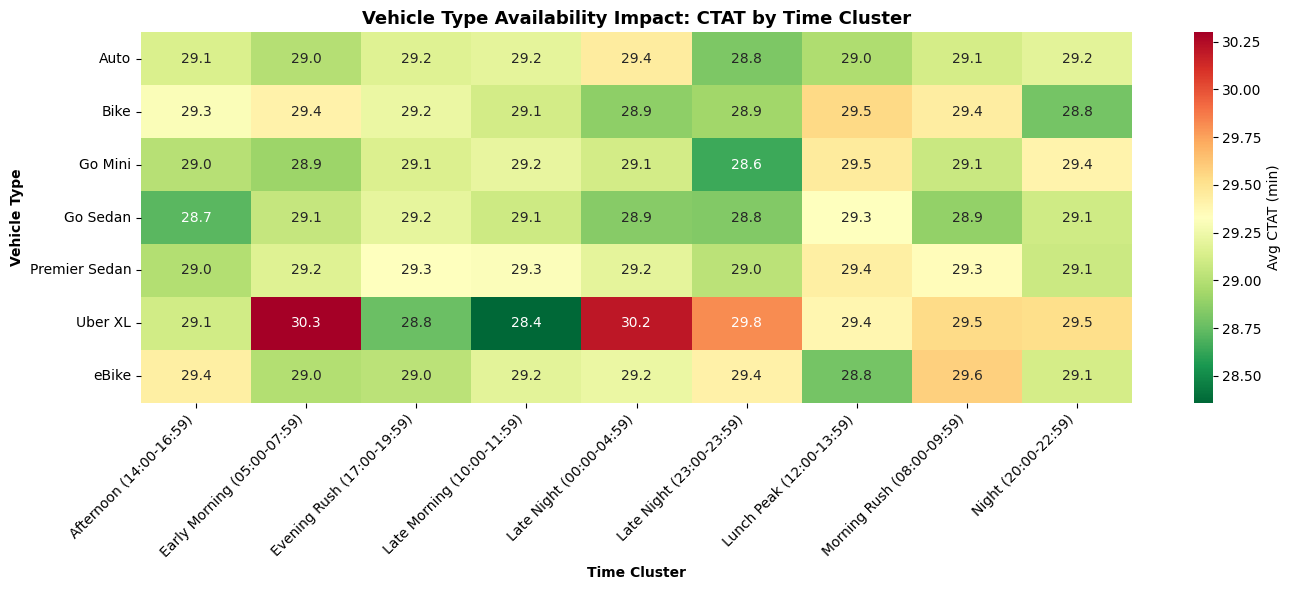

In [108]:
# Analyze impact of vehicle type on CTAT and completion rate
print("="*80)
print("VEHICLE TYPE ANALYSIS")
print("="*80)

# Calculate metrics by vehicle type
vehicle_analysis = df.groupby('Vehicle Type').agg({
    'Booking ID': 'count',
    'Avg CTAT': 'mean',
    'Booking Status': [
        ('Total', 'count'),
        ('Completed', lambda x: (x == 'Completed').sum())
    ],
    'Booking Value': 'mean',
    'Avg VTAT': 'mean'
}).round(2)

vehicle_analysis.columns = ['Total_Bookings', 'Avg_CTAT', 'Total_Rides', 'Completed_Rides', 'Avg_Value', 'Avg_VTAT']
vehicle_analysis['Completion_Rate'] = (vehicle_analysis['Completed_Rides'] / vehicle_analysis['Total_Rides'] * 100).round(2)
vehicle_analysis['Supply_Issue_Score'] = ((vehicle_analysis['Avg_CTAT'] / vehicle_analysis['Avg_CTAT'].min()) * 
                                           (100 / vehicle_analysis['Completion_Rate'])).round(2)

print(vehicle_analysis.sort_values('Supply_Issue_Score', ascending=False))

# Vehicle type by time cluster analysis
vehicle_time = df.copy()
vehicle_time['Time_Cluster'] = vehicle_time['Hour'].apply(assign_time_cluster)

vehicle_time_stats = vehicle_time.groupby(['Vehicle Type', 'Time_Cluster']).agg({
    'Booking ID': 'count',
    'Avg CTAT': 'mean',
    'Booking Status': lambda x: (x == 'Completed').sum() / len(x) * 100
}).round(2)
vehicle_time_stats.columns = ['Bookings', 'Avg_CTAT', 'Completion_Rate']

# Pivot for heatmap
vehicle_ctat_pivot = vehicle_time.groupby(['Vehicle Type', 'Time_Cluster'])['Avg CTAT'].mean().unstack()

plt.figure(figsize=(14, 6))
sns.heatmap(vehicle_ctat_pivot, cmap='RdYlGn_r', annot=True, fmt='.1f', cbar_kws={'label': 'Avg CTAT (min)'})
plt.title('Vehicle Type Availability Impact: CTAT by Time Cluster', fontweight='bold', fontsize=13)
plt.xlabel('Time Cluster', fontweight='bold')
plt.ylabel('Vehicle Type', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [114]:
# Dynamic Surge Pricing Calculator
def calculate_dynamic_surge(avg_ctat, completion_rate, booking_volume, base_multiplier=1.0):
    """
    Calculate surge multiplier based on real-time metrics
    """
    # CTAT factor: Higher CTAT = Higher surge
    if avg_ctat > 15:
        ctat_factor = 1.5
    elif avg_ctat > 10:
        ctat_factor = 1.3
    elif avg_ctat > 7:
        ctat_factor = 1.15
    else:
        ctat_factor = 1.0
    
    # Completion rate factor: Lower completion = Higher surge
    if completion_rate < 50:
        completion_factor = 1.6
    elif completion_rate < 70:
        completion_factor = 1.4
    elif completion_rate < 85:
        completion_factor = 1.2
    else:
        completion_factor = 1.0
    
    # Volume factor: High demand = Higher surge
    if booking_volume > 1000:
        volume_factor = 1.3
    elif booking_volume > 500:
        volume_factor = 1.15
    else:
        volume_factor = 1.0
    
    # Combined multiplier (average of factors)
    surge_multiplier = base_multiplier * ((ctat_factor + completion_factor + volume_factor) / 3)
    
    # Cap at reasonable maximum
    return min(surge_multiplier, 3.0)

# Apply to critical analysis data
criticality['Surge_Multiplier'] = criticality.apply(
    lambda row: calculate_dynamic_surge(row['Avg CTAT'], row['Completion_Rate'], row['Total_Bookings']),
    axis=1
).round(2)

print("\nDYNAMIC SURGE PRICING BY TIME SLOT:")
print(criticality[['DayOfWeek', 'Hour', 'Avg CTAT', 'Completion_Rate', 
                         'Surge_Multiplier']].sort_values('Surge_Multiplier', ascending=False).head(15))


DYNAMIC SURGE PRICING BY TIME SLOT:
   DayOfWeek  Hour   Avg CTAT  Completion_Rate  Surge_Multiplier
16    Friday    16  29.545185        61.887864               1.4
17    Friday    17  28.593738        61.673152               1.4
14    Friday    14  29.110429        61.169703               1.4
15    Friday    15  29.125849        59.602076               1.4
12    Friday    12  29.519146        61.116552               1.4
11    Friday    11  28.850342        62.954186               1.4
10    Friday    10  29.205206        61.572052               1.4
9     Friday     9  28.912729        63.356164               1.4
33    Monday     9  29.414339        61.794020               1.4
32    Monday     8  28.936261        62.183236               1.4
18    Friday    18  29.377261        60.554612               1.4
19    Friday    19  29.141580        61.928934               1.4
39    Monday    15  28.997919        59.948542               1.4
38    Monday    14  29.492029        62.326044       

In [117]:
# Predictive Surge: Identify patterns for pre-emptive pricing
predictive_surge = criticality.copy()

# Create "next hour" prediction by shifting hour
predictive_surge['Next_Hour'] = (predictive_surge['Hour'] + 1) % 24
predictive_surge['Predictive_Surge'] = predictive_surge['Surge_Multiplier']

# Merge to get "upcoming surge" for current hour
surge_forecast = predictive_surge.merge(
    predictive_surge[['DayOfWeek', 'Next_Hour', 'Predictive_Surge']],
    left_on=['DayOfWeek', 'Hour'],
    right_on=['DayOfWeek', 'Next_Hour'],
    how='left',
    suffixes=('_Current', '_Upcoming')
)

print(surge_forecast.columns)

# Apply pre-emptive surge if next hour is critical
surge_forecast['Preemptive_Multiplier'] = surge_forecast.apply(
    lambda row: max(row['Surge_Multiplier'], row['Predictive_Surge'] * 0.7) 
    if pd.notna(row['Predictive_Surge']) else row['Surge_Multiplier'],
    axis=1
).round(2)

print("\nPREDICTIVE SURGE PRICING (30 min advance warning):")
print(surge_forecast[['DayOfWeek', 'Hour', 'Surge_Multiplier', 
                      'Preemptive_Multiplier']].sort_values('Preemptive_Multiplier', ascending=False).head(15))

Index(['DayOfWeek', 'Hour', 'Avg CTAT', 'Total_Bookings', 'Completed_Bookings',
       'Completion_Rate', 'CTAT Normalized', 'CompletionRate_Inverted',
       'Criticality_Score', 'Time_Cluster', 'Day_Type', 'Combined_Cluster',
       'Surge_Multiplier', 'Next_Hour_Current', 'Predictive_Surge_Current',
       'Next_Hour_Upcoming', 'Predictive_Surge_Upcoming'],
      dtype='object')


KeyError: 'Predictive_Surge'